# **User Analytics in the Telecommunication Industry**

## 2. **User Engagement Analysis**

This notebook analyzes customer engagement using session frequency, session duration, and total network traffic. User-level engagement metrics are prepared, normalized, and analyzed using clustering techniques.

## **Required libraries**

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Required libraries imported successfully.")

Required libraries imported successfully.


## 2.1 **Load User-Level Engagement Data**

In [ ]:
# Load the user-level dataset created in the User Overview Analysis

user_level_data = pd.read_csv(
    '../data/processed/user_level_data.csv'
)

print("User-level dataset loaded successfully.")
print("Shape:", user_level_data.shape)

user_level_data.head()

User-level dataset loaded successfully.
Shape: (106856, 14)


,MSISDN/Number,xDR_Sessions,Total_Session_Duration_ms,Total_DL_Bytes,Total_UL_Bytes,Total_Traffic_Bytes,Social Media_Data_Bytes,Google_Data_Bytes,Email_Data_Bytes,YouTube_Data_Bytes,Netflix_Data_Bytes,Gaming_Data_Bytes,Other_Data_Bytes,Duration_Decile
0,3.360100e+10,1,116720.0,8.426375e+08,36053108.0,8.786906e+08,2232135.0,4389005.0,1331362.0,21624548.0,27180981.0,8.124587e+08,386570872.0,6
1,3.360100e+10,1,181230.0,1.207552e+08,36104459.0,1.568596e+08,2660565.0,5334863.0,3307781.0,12432223.0,11221763.0,1.197501e+08,281710071.0,9
2,3.360100e+10,1,134969.0,5.566597e+08,39306820.0,5.959665e+08,3195623.0,3443126.0,3205380.0,21333570.0,19353900.0,5.388277e+08,501693672.0,7
3,3.360101e+10,1,49878.0,4.019932e+08,20327526.0,4.223207e+08,280294.0,9678493.0,2284670.0,6977321.0,1942092.0,3.911261e+08,35279702.0,2
4,3.360101e+10,2,37104.0,1.363130e+09,94280527.0,1.457411e+09,2912542.0,18499616.0,3305469.0,41533002.0,49201724.0,1.314798e+09,804804484.0,2


## 2.2 **Engagement Metrics**

The three key engagement metrics are session frequency, total session duration, and total network traffic.

In [ ]:
# Prepare the three key user engagement metrics

engagement_metrics = user_level_data[
    [
        'MSISDN/Number',
        'xDR_Sessions',
        'Total_Session_Duration_ms',
        'Total_Traffic_Bytes'
    ]
].copy()

print("Engagement metrics prepared successfully.")
print("Shape:", engagement_metrics.shape)

engagement_metrics.head()

Engagement metrics prepared successfully.
Shape: (106856, 4)


,MSISDN/Number,xDR_Sessions,Total_Session_Duration_ms,Total_Traffic_Bytes
0,3.360100e+10,1,116720.0,8.786906e+08
1,3.360100e+10,1,181230.0,1.568596e+08
2,3.360100e+10,1,134969.0,5.959665e+08
3,3.360101e+10,1,49878.0,4.223207e+08
4,3.360101e+10,2,37104.0,1.457411e+09


In [ ]:
# Top 10 customers for each engagement metric

top_10_frequency = engagement_metrics.nlargest(
    10, 'xDR_Sessions'
)[['MSISDN/Number', 'xDR_Sessions']]

top_10_duration = engagement_metrics.nlargest(
    10, 'Total_Session_Duration_ms'
)[['MSISDN/Number', 'Total_Session_Duration_ms']]

top_10_traffic = engagement_metrics.nlargest(
    10, 'Total_Traffic_Bytes'
)[['MSISDN/Number', 'Total_Traffic_Bytes']]


print("Top 10 Customers by Session Frequency")
display(top_10_frequency)

print("\nTop 10 Customers by Session Duration")
display(top_10_duration)

print("\nTop 10 Customers by Total Traffic")
display(top_10_traffic)

Top 10 Customers by Session Frequency


,MSISDN/Number,xDR_Sessions
13526,3.362632e+10,18
6437,3.361489e+10,17
13180,3.362578e+10,17
37052,3.365973e+10,16
76363,3.367588e+10,15
92923,3.376054e+10,15
65118,3.366716e+10,13
666,3.360313e+10,12
1279,3.360452e+10,12
13994,3.362708e+10,12



Top 10 Customers by Session Duration


,MSISDN/Number,Total_Session_Duration_ms
37052,3.365973e+10,2.090190e+06
13526,3.362632e+10,2.044015e+06
6437,3.361489e+10,1.936993e+06
76363,3.367588e+10,1.929843e+06
13180,3.362578e+10,1.894591e+06
92923,3.376054e+10,1.854267e+06
35436,3.365936e+10,1.821879e+06
57241,3.366471e+10,1.621902e+06
106137,3.378632e+10,1.575576e+06
65118,3.366716e+10,1.431357e+06



Top 10 Customers by Total Traffic


,MSISDN/Number,Total_Traffic_Bytes
6437,3.361489e+10,8.846226e+09
92923,3.376054e+10,8.514774e+09
13180,3.362578e+10,8.499621e+09
13526,3.362632e+10,7.971167e+09
76363,3.367588e+10,7.891111e+09
37052,3.365973e+10,7.705863e+09
63028,3.366646e+10,7.308501e+09
92577,3.376041e+10,7.132371e+09
57241,3.366471e+10,6.903961e+09
86455,3.369879e+10,6.540899e+09


In [ ]:
# Normalize the three engagement metrics

scaler = StandardScaler()

engagement_features = engagement_metrics[
    [
        'xDR_Sessions',
        'Total_Session_Duration_ms',
        'Total_Traffic_Bytes'
    ]
].copy()

engagement_normalized = scaler.fit_transform(engagement_features)

engagement_normalized = pd.DataFrame(
    engagement_normalized,
    columns=[
        'Normalized_Session_Frequency',
        'Normalized_Session_Duration',
        'Normalized_Total_Traffic'
    ]
)

print("Engagement metrics normalized successfully.")
print("Shape:", engagement_normalized.shape)

engagement_normalized.head()

Engagement metrics normalized successfully.
Shape: (106856, 3)


,Normalized_Session_Frequency,Normalized_Session_Duration,Normalized_Total_Traffic
0,-0.488564,-0.125690,0.382309
1,-0.488564,0.496334,-1.087677
2,-0.488564,0.050272,-0.193450
3,-0.488564,-0.770201,-0.547074
4,0.752103,-0.893371,1.560854


## 2.3 **Elbow Method for Optimal K**

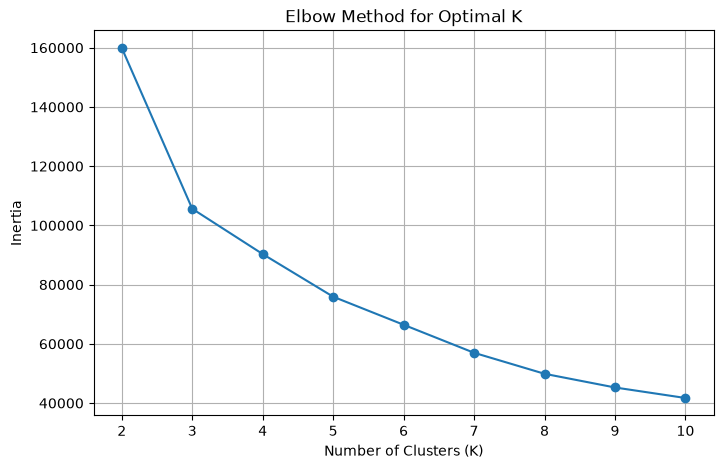

In [ ]:
# Find the optimal number of clusters using the Elbow Method

inertia_values = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    kmeans.fit(engagement_normalized)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    inertia_values,
    marker='o'
)

plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal K')
plt.xticks(range(2, 11))
plt.grid(True)

plt.show()

### Key Insights

- Inertia decreases sharply from K = 2 to K = 3.
- After K = 3, the reductions in inertia become smaller and more gradual.
- Based on the Elbow Method, the practical elbow point is observed around K = 3.
- Therefore, K = 3 is selected for the engagement clustering analysis.

### 2.4 **Engagement Clustering**

Based on the Elbow Method, K = 3 is selected for customer engagement clustering.
The three engagement metrics are normalized before applying K-Means clustering.

In [ ]:
# Normalize engagement metrics and apply K-Means clustering

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Select engagement metrics
engagement_metrics = [
    'xDR_Sessions',
    'Total_Session_Duration_ms',
    'Total_Traffic_Bytes'
]

# Create a copy of engagement data
engagement_data = user_level_data[['MSISDN/Number'] + engagement_metrics].copy()

# Standardize the engagement metrics
scaler_engagement = StandardScaler()
engagement_scaled = scaler_engagement.fit_transform(
    engagement_data[engagement_metrics]
)

# Apply K-Means clustering with K = 3
kmeans_engagement = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

engagement_data['Engagement_Cluster'] = kmeans_engagement.fit_predict(
    engagement_scaled
)

print("Engagement clustering completed successfully.")
print("Number of clusters:", engagement_data['Engagement_Cluster'].nunique())

# Display cluster distribution
print("\nCustomer count per cluster:")
print(
    engagement_data['Engagement_Cluster']
    .value_counts()
    .sort_index()
)

# Assign meaningful engagement labels to the clusters

engagement_level_map = {
    0: 'High Engagement',
    1: 'Low Engagement',
    2: 'Medium Engagement'
}

engagement_data['Engagement_Level'] = engagement_data[
    'Engagement_Cluster'
].map(engagement_level_map)

print("Engagement levels assigned successfully.")

# Display engagement level distribution
print("\nCustomer count by engagement level:")
print(
    engagement_data['Engagement_Level']
    .value_counts()
)

Engagement clustering completed successfully.
Number of clusters: 3

Customer count per cluster:
Engagement_Cluster
0     4409
1    79971
2    22476
Name: count, dtype: int64
Engagement levels assigned successfully.

Customer count by engagement level:
Engagement_Level
Low Engagement       79971
Medium Engagement    22476
High Engagement       4409
Name: count, dtype: int64


### 2.5 **Cluster-wise Engagement Metrics**

For each engagement cluster, compute the minimum, maximum, average, and total values of the non-normalized engagement metrics.

In [ ]:
# Compute cluster-wise engagement metrics

cluster_engagement_summary = (
    engagement_data
    .groupby('Engagement_Cluster')[engagement_metrics]
    .agg(['min', 'max', 'mean', 'sum'])
)

# Display the summary
print("Cluster-wise Engagement Metrics:")
display(cluster_engagement_summary)

Cluster-wise Engagement Metrics:


xDR_Sessions                       \
                            min max      mean    sum   
Engagement_Cluster                                     
0                             3  18  4.182581  18441   
1                             1   2  1.029136  82301   
2                             1   4  2.144198  48193   

                   Total_Session_Duration_ms                               \
                                         min           max           mean   
Engagement_Cluster                                                          
0                                    85554.0  2.090190e+06  447436.128002   
1                                     7142.0  2.449000e+05   94069.198869   
2                                    18235.0  5.143160e+05  194410.893921   

                                 Total_Traffic_Bytes                \
                             sum                 min           max   
Engagement_Cluster                                                   
0                   1.972746e+09         661851764.0  8.846226e+09   
1                   7.522808e+09          33249009.0  9.584016e+08   
2                   4.369579e+09         166910132.0  2.509057e+09   

                                                
                            mean           sum  
Engagement_Cluster                              
0                   2.161402e+09  9.529620e+12  
1                   4.977669e+08  3.980692e+13  
2                   1.089901e+09  2.449662e+13

### Key Insights

* Cluster 0 represents the **High Engagement** group, with the highest average session frequency, session duration, and total traffic.
* Cluster 1 represents the **Low Engagement** group, with the lowest average values across all three engagement metrics.
* Cluster 2 represents the **Medium Engagement** group, with engagement levels between Cluster 0 and Cluster 1.
* Although Cluster 0 has fewer customers, it has the highest average traffic usage per customer, indicating relatively intensive usage among its members.


### 2.6 **Top 10 Customers per Engagement Metric**

Identify the top 10 customers based on each engagement metric:
- Session frequency
- Total session duration
- Total traffic

In [ ]:
# Identify top 10 customers for each engagement metric

top_10_engagement_customers = {}

for metric in engagement_metrics:
    top_10 = (
        engagement_data[['MSISDN/Number', metric]]
        .sort_values(by=metric, ascending=False)
        .head(10)
        .reset_index(drop=True)
    )
    
    top_10_engagement_customers[metric] = top_10
    
    print(f"\nTop 10 Customers by {metric}:")
    display(top_10)


Top 10 Customers by xDR_Sessions:


,MSISDN/Number,xDR_Sessions
0,3.362632e+10,18
1,3.361489e+10,17
2,3.362578e+10,17
3,3.365973e+10,16
4,3.367588e+10,15
5,3.376054e+10,15
6,3.366716e+10,13
7,3.360452e+10,12
8,3.376041e+10,12
9,3.360313e+10,12



Top 10 Customers by Total_Session_Duration_ms:


,MSISDN/Number,Total_Session_Duration_ms
0,3.365973e+10,2.090190e+06
1,3.362632e+10,2.044015e+06
2,3.361489e+10,1.936993e+06
3,3.367588e+10,1.929843e+06
4,3.362578e+10,1.894591e+06
5,3.376054e+10,1.854267e+06
6,3.365936e+10,1.821879e+06
7,3.366471e+10,1.621902e+06
8,3.378632e+10,1.575576e+06
9,3.366716e+10,1.431357e+06



Top 10 Customers by Total_Traffic_Bytes:


,MSISDN/Number,Total_Traffic_Bytes
0,3.361489e+10,8.846226e+09
1,3.376054e+10,8.514774e+09
2,3.362578e+10,8.499621e+09
3,3.362632e+10,7.971167e+09
4,3.367588e+10,7.891111e+09
5,3.365973e+10,7.705863e+09
6,3.366646e+10,7.308501e+09
7,3.376041e+10,7.132371e+09
8,3.366471e+10,6.903961e+09
9,3.369879e+10,6.540899e+09


In [ ]:
# Display MSISDN numbers as full customer IDs

for metric, table in top_10_engagement_customers.items():
    table['MSISDN/Number'] = table['MSISDN/Number'].apply(
        lambda x: f"{int(x)}"
    )

# Display the updated Top 10 customer tables

for metric, table in top_10_engagement_customers.items():
    print(f"\nTop 10 Customers by {metric}:")
    display(table)

print("\nTop 10 customer tables prepared with full MSISDN numbers.")


Top 10 Customers by xDR_Sessions:


,MSISDN/Number,xDR_Sessions
0,33626320676,18
1,33614892860,17
2,33625779332,17
3,33659725664,16
4,33675877202,15
5,33760536639,15
6,33667163239,13
7,33604515716,12
8,33760413819,12
9,33603127838,12



Top 10 Customers by Total_Session_Duration_ms:


,MSISDN/Number,Total_Session_Duration_ms
0,33659725664,2.090190e+06
1,33626320676,2.044015e+06
2,33614892860,1.936993e+06
3,33675877202,1.929843e+06
4,33625779332,1.894591e+06
5,33760536639,1.854267e+06
6,33659359429,1.821879e+06
7,33664712899,1.621902e+06
8,33786323068,1.575576e+06
9,33667163239,1.431357e+06



Top 10 Customers by Total_Traffic_Bytes:


,MSISDN/Number,Total_Traffic_Bytes
0,33614892860,8.846226e+09
1,33760536639,8.514774e+09
2,33625779332,8.499621e+09
3,33626320676,7.971167e+09
4,33675877202,7.891111e+09
5,33659725664,7.705863e+09
6,33666464084,7.308501e+09
7,33760413819,7.132371e+09
8,33664712899,6.903961e+09
9,33698792269,6.540899e+09



Top 10 customer tables prepared with full MSISDN numbers.


### **Key Insights**

* The top 10 customers vary across session frequency, total session duration, and total traffic, indicating different patterns of user engagement.
* Customers with the highest session frequency are not necessarily the same customers with the highest session duration or total traffic.
* The top customers based on total traffic represent users with relatively high overall data consumption.
* Comparing the top 10 customers across all three metrics helps identify customers with different patterns of engagement intensity and network usage.


### 2.7 **Top 10 Engaged Users per Application**

Identify the top 10 users based on total data traffic for each application.
The analysis covers Social Media, Google, Email, YouTube, Netflix, Gaming, and Other.

In [ ]:
# Top 10 Engaged Users per Application

application_engagement_columns = {
    'Social Media': 'Social Media_Data_Bytes',
    'Google': 'Google_Data_Bytes',
    'Email': 'Email_Data_Bytes',
    'YouTube': 'YouTube_Data_Bytes',
    'Netflix': 'Netflix_Data_Bytes',
    'Gaming': 'Gaming_Data_Bytes',
    'Other': 'Other_Data_Bytes'
}

top_10_application_users = {}

for application, column in application_engagement_columns.items():

    top_users = (
        user_level_data[['MSISDN/Number', column]]
        .sort_values(by=column, ascending=False)
        .head(10)
        .copy()
    )

    # Display full MSISDN numbers
    top_users['MSISDN/Number'] = top_users['MSISDN/Number'].apply(
        lambda x: f"{int(x)}"
    )

    top_10_application_users[application] = top_users

    print(f"\nTop 10 Engaged Users for {application}:")
    display(top_users)

print("\nTop 10 engaged users per application prepared successfully.")


Top 10 Engaged Users for Social Media:


,MSISDN/Number,Social Media_Data_Bytes
13526,33626320676,43374779.0
92923,33760536639,39783189.0
37052,33659725664,35412358.0
6437,33614892860,28294544.0
13180,33625779332,27135500.0
65118,33667163239,24247850.0
106137,33786323068,23974919.0
70960,33669068942,23800834.0
666,33603127838,23077825.0
31331,33658490784,23000066.0



Top 10 Engaged Users for Google:


,MSISDN/Number,Google_Data_Bytes
13526,33626320676,152191852.0
13180,33625779332,142307915.0
6437,33614892860,127973787.0
92923,33760536639,123223099.0
37052,33659725664,116516345.0
106137,33786323068,110254484.0
76363,33675877202,109860502.0
65118,33667163239,105032696.0
94654,33761268199,97089988.0
86313,33698756430,91935151.0



Top 10 Engaged Users for Email:


...


Top 10 Engaged Users for Gaming:


,MSISDN/Number,Gaming_Data_Bytes
6437,33614892860,7.749432e+09
92923,33760536639,7.461045e+09
13180,33625779332,7.326673e+09
76363,33675877202,6.970568e+09
13526,33626320676,6.887572e+09
37052,33659725664,6.725559e+09
63028,33666464084,6.646303e+09
92577,33760413819,6.268620e+09
57241,33664712899,6.103856e+09
86455,33698792269,5.753743e+09



Top 10 Engaged Users for Other:


,MSISDN/Number,Other_Data_Bytes
13526,33626320676,8.167878e+09
6437,33614892860,7.639264e+09
76363,33675877202,6.798515e+09
13180,33625779332,6.354583e+09
666,33603127838,6.326671e+09
37052,33659725664,6.317415e+09
13936,33626948251,5.305448e+09
13994,33627080969,5.117791e+09
94654,33761268199,5.077779e+09
30715,33658361927,5.013651e+09



Top 10 engaged users per application prepared successfully.


### **Key Insights**

* The top 10 engaged users were identified separately for Social Media, Google, Email, YouTube, Netflix, Gaming, and Other applications based on total data traffic.
* The users with the highest engagement can differ across applications, indicating different patterns of application usage among customers.
* Application-level analysis helps identify users with particularly high data consumption for specific services.
* These results provide a detailed view of user engagement beyond overall network usage and can be used to understand application-specific usage patterns.


### 2.8 **Top 3 Most Used Applications**

The total data usage is aggregated for each application across all users. The three applications with the highest total data usage are identified and visualized to understand the most heavily used services.

Top 3 Most Used Applications:


,Application,Total_Data_Bytes
0,Gaming,6.408892e+13
1,Other,6.395425e+13
2,YouTube,3.372204e+12


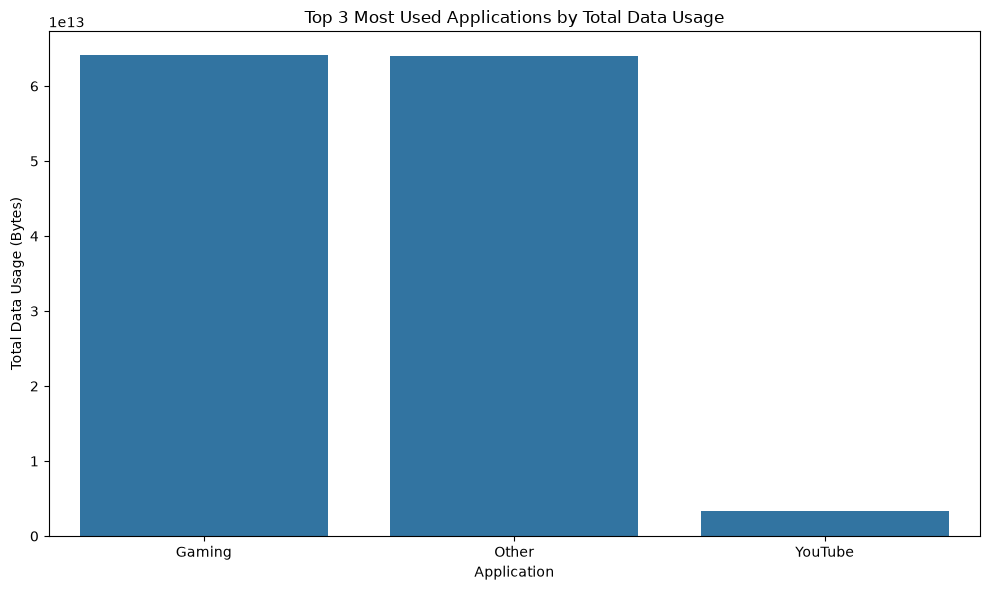

In [ ]:
# Top 3 Most Used Applications

application_columns = {
    'Social Media': 'Social Media_Data_Bytes',
    'Google': 'Google_Data_Bytes',
    'Email': 'Email_Data_Bytes',
    'YouTube': 'YouTube_Data_Bytes',
    'Netflix': 'Netflix_Data_Bytes',
    'Gaming': 'Gaming_Data_Bytes',
    'Other': 'Other_Data_Bytes'
}

# Calculate total data usage for each application
application_total_usage = {}

for application, column in application_columns.items():
    application_total_usage[application] = user_level_data[column].sum()

# Convert to DataFrame
application_usage_df = pd.DataFrame(
    list(application_total_usage.items()),
    columns=['Application', 'Total_Data_Bytes']
)

# Sort applications by total data usage
application_usage_df = application_usage_df.sort_values(
    by='Total_Data_Bytes',
    ascending=False
).reset_index(drop=True)

# Select top 3 applications
top_3_applications = application_usage_df.head(3)

print("Top 3 Most Used Applications:")
display(top_3_applications)

# Plot top 3 applications
plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_3_applications,
    x='Application',
    y='Total_Data_Bytes'
)

plt.title('Top 3 Most Used Applications by Total Data Usage')
plt.xlabel('Application')
plt.ylabel('Total Data Usage (Bytes)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

### **Key Insights**

- Gaming has the highest total data usage among the top three applications.
- Other is the second-highest application in terms of total data usage and is close to Gaming.
- YouTube has substantially lower total data usage compared with Gaming and Other.
- The results indicate that Gaming and Other contribute the largest share of data traffic among the seven analyzed applications.

### 2.9 **Optimized K using Elbow Method**

The Elbow Method is used to determine the optimized number of clusters for user engagement analysis. The value of K is selected by identifying the point where the reduction in within-cluster sum of squares (inertia) becomes relatively gradual.

In [ ]:
# Display Elbow Method results

elbow_results = pd.DataFrame({
    'K': range(2, 11),
    'Inertia': inertia_values
})

display(elbow_results)

print("Based on the Elbow Method, the elbow point is observed around K = 3.")
print("Therefore, K = 3 is used as the optimized number of engagement clusters.")

,K,Inertia
0,2,159909.049419
1,3,105612.856625
2,4,90316.482919
3,5,75914.056411
4,6,66443.472278
5,7,56975.902779
6,8,49887.606215
7,9,45263.407844
8,10,41711.349084


Based on the Elbow Method, the elbow point is observed around K = 3.
Therefore, K = 3 is used as the optimized number of engagement clusters.


### Key Insights

- The largest reduction in inertia occurs from K = 2 to K = 3.
- After K = 3, the reductions in inertia become smaller and more gradual.
- The Elbow Method indicates K = 3 as the practical elbow point for the engagement data.
- K = 3 is therefore used for the final engagement clustering.

### 2.10 **Engagement Cluster Visualization**

The engagement clusters are visualized using session frequency and total network traffic. This visualization helps understand the differences in network activity across the identified customer engagement groups.

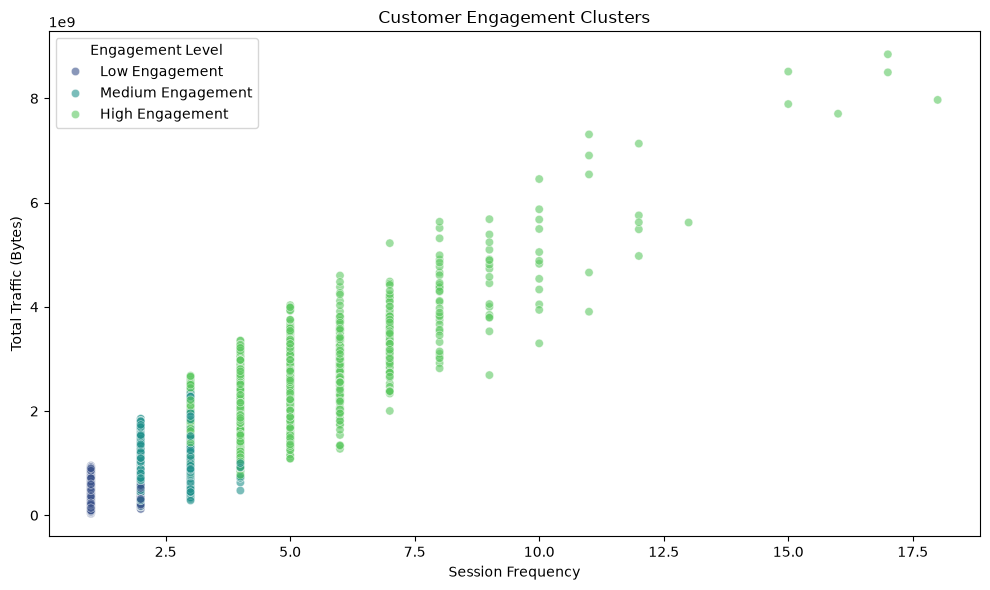

In [ ]:
# Visualize Engagement Clusters using meaningful engagement levels

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=engagement_data,
    x='xDR_Sessions',
    y='Total_Traffic_Bytes',
    hue='Engagement_Level',
    hue_order=[
        'Low Engagement',
        'Medium Engagement',
        'High Engagement'
    ],
    palette='viridis',
    alpha=0.6
)

plt.title('Customer Engagement Clusters')
plt.xlabel('Session Frequency')
plt.ylabel('Total Traffic (Bytes)')
plt.legend(title='Engagement Level')
plt.tight_layout()
plt.show()

### Key Insights

- The visualization shows distinct engagement patterns across the three customer groups.
- **Low Engagement** customers generally have lower session frequency and lower overall traffic usage.
- **Medium Engagement** customers show engagement levels between the Low and High Engagement groups.
- **High Engagement** customers generally show higher session frequency and greater traffic usage.
- Some overlap between the engagement groups is visible because this visualization represents only two engagement metrics, while the clustering considers all three engagement metrics, including total session duration.

In [ ]:
# Save the final customer-level engagement data for Task 4

import os

os.makedirs('../outputs', exist_ok=True)

engagement_data.to_csv(
    '../outputs/user_engagement_metrics.csv',
    index=False
)

print("Engagement metrics saved successfully.")
print("Shape:", engagement_data.shape)
print("File:", '../outputs/user_engagement_metrics.csv')

Engagement metrics saved successfully.
Shape: (106856, 6)
File: ../outputs/user_engagement_metrics.csv


## Final Summary

- Three key engagement metrics were used: session frequency, total session duration, and total network traffic.
- The Elbow Method identified K = 3 as the practical number of engagement clusters.
- The three customer groups were interpreted as **High Engagement, Medium Engagement, and Low Engagement** based on their average engagement metrics.
- Top customers were identified separately for session frequency, session duration, and total traffic.
- Application-level analysis was performed to identify highly engaged users for Social Media, Google, Email, YouTube, Netflix, Gaming, and Other applications.
- Gaming, Other, and YouTube were identified as the top three applications by total data usage.
- The final customer-level engagement dataset was saved with engagement metrics, cluster numbers, and meaningful engagement levels.